# Count patch success/fail

Этот ноутбук нужен только для разметки датасета на success/fail тем же способом, что и в `patch_success_analysis_soft_metrics.ipynb`: считаем confidence на чистой и patched картинке, берём `drop = conf_clean - conf_patch`, success если `drop > success_thresh`. SegmentIG, Full IG, NAA и любые метрики здесь не считаются.


## Параметры

`dataset_path` может быть строкой или списком строк. Если `count_all_images=True`, ноутбук сначала посчитает все картинки в указанных папках и поставит `pool_size` равным этому числу. Если датасет большой и хочется быструю оценку, поставь `count_all_images=False` и руками задай `pool_size`.

`inference_batch_size` управляет памятью и скоростью YOLO inference. Для MPS я бы начинал с `8`; если память растёт слишком сильно, ставь `4` или `2`. При ошибке на batch код автоматически дробит пачку меньше, поэтому единичный плохой batch не должен ломать весь прогон.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# Можно передать один путь или несколько путей.
dataset_path = ["../datasets/COCO_people"]

patch_path = "../data/patch.png"
model_path = "yolo11s.pt"
output_dir = "new_experiments/outputs/patch_success_count_success_fail"

# Если True, считаем весь датасет. Если False, берём случайный subset размера pool_size.
count_all_images = True
pool_size = 2000

success_thresh = 0.30
seed = 17
device = "mps"
inference_batch_size = 32
show_progress = True

# Обычно менять не надо: это те же параметры, что использовались в основном ноутбуке.
imgsz = 640
conf = 0.01
target_class_name = "person"
apply_patch_after_letterbox = True
patch_xy = (0, 0)
force_recompute = False


## Расчёт attack cache

Здесь строится только attack cache. Важный момент: `pool_success` и `pool_fail` — это реальные количества success/fail среди просмотренного pool. `balanced_success` и `balanced_fail` — это уже сэмпл после ограничения `n_success/n_fail`, он нужен старому пайплайну метрик, но для ответа “сколько success/fail в датасете” смотрим именно на `pool_*`.


In [2]:
repo_root = Path.cwd()
if not (repo_root / "new_experiments" / "patch_success_analysis").exists():
    repo_root = Path.cwd().parent
if str(repo_root / "new_experiments") not in sys.path:
    sys.path.insert(0, str(repo_root / "new_experiments"))

from patch_success_analysis import AttackConfig, ExperimentConfig, PatchSuccessExperiment
from patch_success_analysis.data import list_image_paths

image_paths = list_image_paths(dataset_path)
n_images = len(image_paths)
effective_pool_size = n_images if count_all_images else int(pool_size)

if n_images == 0:
    raise RuntimeError(f"No images found in dataset_path={dataset_path!r}")

attack_config = AttackConfig(
    dataset_path=dataset_path,
    patch_path=patch_path,
    model_path=model_path,
    output_dir=output_dir,
    imgsz=imgsz,
    device=device,
    target_class_name=target_class_name,
    conf=conf,
    success_thresh=success_thresh,
    seed=seed,
    pool_size=effective_pool_size,
    # Ставим достаточно большими, чтобы balanced cache не обрезал классы при обычных размерах.
    # Для финального count всё равно используем pool_success/pool_fail из pool_summary.
    n_success=effective_pool_size,
    n_fail=effective_pool_size,
    inference_batch_size=inference_batch_size,
    show_progress=show_progress,
    apply_patch_after_letterbox=apply_patch_after_letterbox,
    patch_xy=patch_xy,
)

config = ExperimentConfig(attack=attack_config)
exp = PatchSuccessExperiment(config)
cache = exp.build_or_load_cache(force=force_recompute)

summary = cache.to_summary()
print(f"images_found={n_images}")
print(f"pool_size_requested={effective_pool_size}")
print(f"cache_path={attack_config.cache_path}")


Patch success/fail:   0%|          | 0/7343 [00:00<?, ?img/s]

WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s e

## Итоговые количества

Основная строка — `pool`: это количество success/fail среди реально обработанных картинок. Если какие-то картинки не удалось прочитать или обработать, они попадут в `pool_failed_images`.


,scope,total,success,fail,failed_images,success_rate
0,pool,6362,3762,2600,981,0.591323
1,balanced_cache,6362,3762,2600,981,0.591323


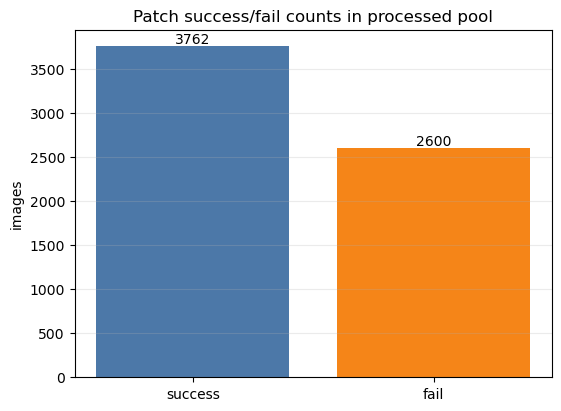

In [3]:
pool_total = int(summary.get("pool_total", 0))
pool_success = int(summary.get("pool_success", 0))
pool_fail = int(summary.get("pool_fail", 0))
pool_failed_images = int(summary.get("pool_failed_images", 0))

balanced_success = int(summary.get("balanced_success", 0))
balanced_fail = int(summary.get("balanced_fail", 0))

counts_df = pd.DataFrame([
    {
        "scope": "pool",
        "total": pool_total,
        "success": pool_success,
        "fail": pool_fail,
        "failed_images": pool_failed_images,
        "success_rate": pool_success / pool_total if pool_total else float("nan"),
    },
    {
        "scope": "balanced_cache",
        "total": balanced_success + balanced_fail,
        "success": balanced_success,
        "fail": balanced_fail,
        "failed_images": pool_failed_images,
        "success_rate": balanced_success / (balanced_success + balanced_fail) if (balanced_success + balanced_fail) else float("nan"),
    },
])
display(counts_df)

fig, ax = plt.subplots(figsize=(5.5, 4), constrained_layout=True)
bars = ax.bar(["success", "fail"], [pool_success, pool_fail], color=["#4C78A8", "#F58518"])
for bar in bars:
    h = int(bar.get_height())
    ax.text(bar.get_x() + bar.get_width() / 2, h, str(h), ha="center", va="bottom")
ax.set_title("Patch success/fail counts in processed pool")
ax.set_ylabel("images")
ax.grid(axis="y", alpha=0.25)
plt.show()


## Детальная таблица

Если нужно проверить границу между success/fail, ниже есть все обработанные картинки с `conf_clean`, `conf_patch`, `drop` и флагом `success`.


,path,success,conf_clean,conf_patch,drop
0,../datasets/COCO_people/03549_train2017_image3...,True,0.948747,0.0,0.948747
1,../datasets/COCO_people/00967_train2017_image2...,True,0.947966,0.0,0.947966
2,../datasets/COCO_people/05673_train2017_image3...,True,0.946332,0.0,0.946332
3,../datasets/COCO_people/04094_train2017_image1...,True,0.945791,0.0,0.945791
4,../datasets/COCO_people/00385_train2017_image4...,True,0.944681,0.0,0.944681
5,../datasets/COCO_people/04057_train2017_image3...,True,0.942838,0.0,0.942838
6,../datasets/COCO_people/02268_train2017_image7...,True,0.942735,0.0,0.942735
7,../datasets/COCO_people/04953_train2017_image2...,True,0.941863,0.0,0.941863
8,../datasets/COCO_people/01244_train2017_image3...,True,0.941812,0.0,0.941812
9,../datasets/COCO_people/01846_train2017_image2...,True,0.941692,0.0,0.941692


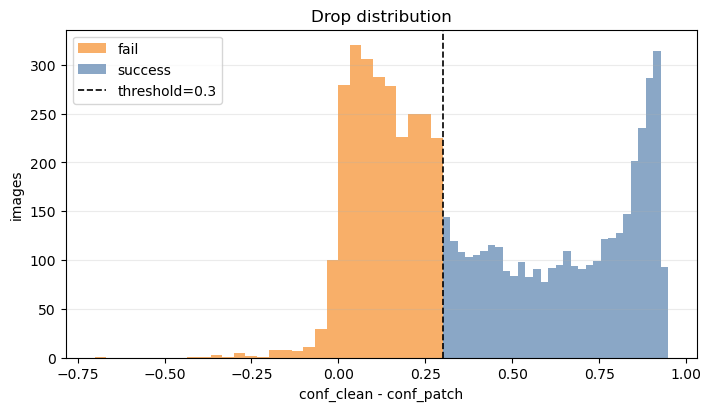

In [4]:
examples_df = pd.DataFrame([item.to_dict() for item in cache.examples])
examples_df = examples_df.sort_values("drop", ascending=False).reset_index(drop=True)
display(examples_df[["path", "success", "conf_clean", "conf_patch", "drop"]].head(20))

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
if len(examples_df):
    ax.hist(examples_df.loc[~examples_df["success"], "drop"], bins=30, alpha=0.65, label="fail", color="#F58518")
    ax.hist(examples_df.loc[examples_df["success"], "drop"], bins=30, alpha=0.65, label="success", color="#4C78A8")
ax.axvline(success_thresh, color="black", linestyle="--", linewidth=1.2, label=f"threshold={success_thresh}")
ax.set_title("Drop distribution")
ax.set_xlabel("conf_clean - conf_patch")
ax.set_ylabel("images")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()


## Сохранение side-by-side примеров

Если `save_attack_examples=True`, эта ячейка сохраняет успешные примеры в `celeb_sucess`, а неуспешные в `celeb_fail`. Слева сохраняется clean letterbox-картинка с целевой детекцией человека, справа — patched-вариант с детекцией человека, если YOLO её нашёл.


In [5]:
save_attack_examples = True
success_examples_dir = "coco_sucess"
fail_examples_dir = "coco_fail"
max_saved_per_class = 500
display_detection_conf_threshold = 0.30

if save_attack_examples:
    from PIL import Image, ImageDraw
    from tqdm.auto import tqdm

    from patch_success_analysis.patching import build_clean_and_patched_letterboxed
    from patch_success_analysis.yolo import (
        detection_dict_from_result,
        get_class_id,
        load_yolo,
        yolo_predict_conf_batch,
    )

    export_success_dir = Path(success_examples_dir)
    export_fail_dir = Path(fail_examples_dir)
    export_success_dir.mkdir(parents=True, exist_ok=True)
    export_fail_dir.mkdir(parents=True, exist_ok=True)

    yolo = load_yolo(model_path, device=device)
    names = getattr(yolo, "names", getattr(getattr(yolo, "model", None), "names", {}))
    export_target_class_id = get_class_id(names, target_class_name) if target_class_name is not None else None
    patch_pil = Image.open(patch_path).convert("RGB")

    def visible_detection(det):
        if det is None:
            return None
        if float(det.get("confidence", 0.0)) < float(display_detection_conf_threshold):
            return None
        return det

    def draw_detection(image, det, *, color):
        out = image.copy().convert("RGB")
        draw = ImageDraw.Draw(out)
        det = visible_detection(det)
        if det is None:
            return out
        x1, y1, x2, y2 = [float(v) for v in det["bbox_xyxy_orig"]]
        draw.rectangle((x1, y1, x2, y2), outline=color, width=4)
        label = f"{float(det['confidence']):.3f}"
        try:
            text_box = draw.textbbox((0, 0), label)
            text_w = text_box[2] - text_box[0]
            text_h = text_box[3] - text_box[1]
        except Exception:
            text_w, text_h = 40, 12
        label_x = max(0, int(x1))
        label_y = max(0, int(y1) - text_h - 8)
        draw.rectangle((label_x, label_y, label_x + text_w + 10, label_y + text_h + 8), fill=color)
        draw.text((label_x + 5, label_y + 4), label, fill=(255, 255, 255))
        return out

    def make_side_by_side(clean_img, patched_img, clean_det, patched_det, example):
        clean_color = (76, 120, 168)
        patched_color = (245, 133, 24) if example.success else clean_color
        clean_panel = draw_detection(clean_img, clean_det, color=clean_color)
        patched_panel = draw_detection(patched_img, patched_det, color=patched_color)
        gap = 8
        width = clean_panel.width + gap + patched_panel.width
        height = max(clean_panel.height, patched_panel.height)
        canvas = Image.new("RGB", (width, height), (255, 255, 255))
        canvas.paste(clean_panel, (0, 0))
        canvas.paste(patched_panel, (clean_panel.width + gap, 0))
        return canvas

    export_examples = list(cache.examples)
    if max_saved_per_class is not None:
        successes = [item for item in export_examples if item.success][: int(max_saved_per_class)]
        failures = [item for item in export_examples if not item.success][: int(max_saved_per_class)]
        export_examples = successes + failures

    saved_rows = []
    batch_records = []
    for idx, example in enumerate(tqdm(export_examples, desc="Prepare side-by-side examples", unit="img")):
        try:
            with Image.open(example.path) as image:
                base_pil = image.convert("RGB")
            clean_lb, patched_lb, _patch_bbox = build_clean_and_patched_letterboxed(base_pil, patch_pil, attack_config)
            batch_records.append((idx, example, clean_lb, patched_lb))
        except Exception as exc:
            saved_rows.append({"path": example.path, "success": example.success, "saved_path": None, "error": f"{type(exc).__name__}: {exc}"})

    for start in tqdm(range(0, len(batch_records), inference_batch_size), desc="Detect exported examples", unit="batch"):
        records = batch_records[start : start + inference_batch_size]
        _clean_confs, clean_results = yolo_predict_conf_batch(
            yolo,
            [record[2] for record in records],
            imgsz=imgsz,
            target_class_id=export_target_class_id,
            conf=conf,
            device=device,
            batch_size=inference_batch_size,
        )
        _patched_confs, patched_results = yolo_predict_conf_batch(
            yolo,
            [record[3] for record in records],
            imgsz=imgsz,
            target_class_id=export_target_class_id,
            conf=conf,
            device=device,
            batch_size=inference_batch_size,
        )
        for (idx, example, clean_lb, patched_lb), clean_res, patched_res in zip(records, clean_results, patched_results, strict=True):
            clean_det = example.clean_detection or detection_dict_from_result(clean_res, target_class_id=export_target_class_id)
            patched_det = detection_dict_from_result(patched_res, target_class_id=export_target_class_id)
            side_by_side = make_side_by_side(clean_lb, patched_lb, clean_det, patched_det, example)
            group_dir = export_success_dir if example.success else export_fail_dir
            stem = Path(example.path).stem
            out_path = group_dir / f"{idx:06d}_{stem}_drop_{example.drop:.3f}.png"
            side_by_side.save(out_path)
            saved_rows.append({"path": example.path, "success": example.success, "saved_path": str(out_path), "error": None})

    saved_examples_df = pd.DataFrame(saved_rows)
    display(saved_examples_df.groupby("success", dropna=False).size().rename("saved"))
    display(saved_examples_df.head(20))
else:
    print("save_attack_examples=False; export skipped.")


Prepare side-by-side examples:   0%|          | 0/1000 [00:00<?, ?img/s]

Detect exported examples:   0%|          | 0/32 [00:00<?, ?batch/s]

WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s exceeded
WARNING ⚠️ NMS time limit 3.600s e

success
False    500
True     500
Name: saved, dtype: int64

,path,success,saved_path,error
0,../datasets/COCO_people/01892_train2017_image4...,True,coco_sucess/000000_01892_train2017_image423668...,None
1,../datasets/COCO_people/05348_train2017_image1...,True,coco_sucess/000001_05348_train2017_image126950...,None
2,../datasets/COCO_people/03298_train2017_image2...,True,coco_sucess/000002_03298_train2017_image217661...,None
3,../datasets/COCO_people/06162_train2017_image2...,True,coco_sucess/000003_06162_train2017_image273204...,None
4,../datasets/COCO_people/03226_train2017_image2...,True,coco_sucess/000004_03226_train2017_image25595_...,None
5,../datasets/COCO_people/03354_train2017_image1...,True,coco_sucess/000005_03354_train2017_image174090...,None
6,../datasets/COCO_people/03064_train2017_image3...,True,coco_sucess/000006_03064_train2017_image372180...,None
7,../datasets/COCO_people/05660_train2017_image4...,True,coco_sucess/000007_05660_train2017_image401707...,None
8,../datasets/COCO_people/06862_train2017_image4...,True,coco_sucess/000008_06862_train2017_image440534...,None
9,../datasets/COCO_people/00233_train2017_image4...,True,coco_sucess/000009_00233_train2017_image446181...,None


## Ошибки чтения/обработки

Если `pool_failed_images > 0`, здесь будут первые 50 путей с ошибками.


In [ ]:
failed_paths = summary.get("failed_paths", [])
if failed_paths:
    display(pd.DataFrame({"failed_path": failed_paths}))
else:
    print("No failed images in processed pool.")


,failed_path
0,../datasets/COCO_people/06530_train2017_image3...
1,../datasets/COCO_people/00905_train2017_image2...
2,../datasets/COCO_people/06424_train2017_image4...
3,../datasets/COCO_people/04713_train2017_image1...
4,../datasets/COCO_people/01713_train2017_image2...
5,../datasets/COCO_people/00066_train2017_image3...
6,../datasets/COCO_people/03225_train2017_image2...
7,../datasets/COCO_people/00634_train2017_image2...
8,../datasets/COCO_people/05591_train2017_image3...
9,../datasets/COCO_people/03582_train2017_image2...


: 